In [1]:
checkpoint = "ustc-community/dfine-nano-coco"
image_size = 800

In [2]:
from coco_dataset_loader import CocoDatasetLoader
from datasets import DatasetDict

coco_loader = CocoDatasetLoader("../../dataset/MSGOv2_small")

In [3]:
dataset = DatasetDict()

for split in ["train", "valid", "test"]:
    hf_dataset = coco_loader.load_coco_hf_dataset(split)
    if len(hf_dataset) > 0:
        dataset[split] = hf_dataset
        print(hf_dataset)

print(dataset)

Casting the dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'image_id', 'image', 'file_name', 'width', 'height', 'objects'],
    num_rows: 100
})


Casting the dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'image_id', 'image', 'file_name', 'width', 'height', 'objects'],
    num_rows: 20
})


Casting the dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'image_id', 'image', 'file_name', 'width', 'height', 'objects'],
    num_rows: 20
})
DatasetDict({
    train: Dataset({
        features: ['id', 'image_id', 'image', 'file_name', 'width', 'height', 'objects'],
        num_rows: 100
    })
    valid: Dataset({
        features: ['id', 'image_id', 'image', 'file_name', 'width', 'height', 'objects'],
        num_rows: 20
    })
    test: Dataset({
        features: ['id', 'image_id', 'image', 'file_name', 'width', 'height', 'objects'],
        num_rows: 20
    })
})


dict_keys(['id', 'image_id', 'image', 'file_name', 'width', 'height', 'objects'])


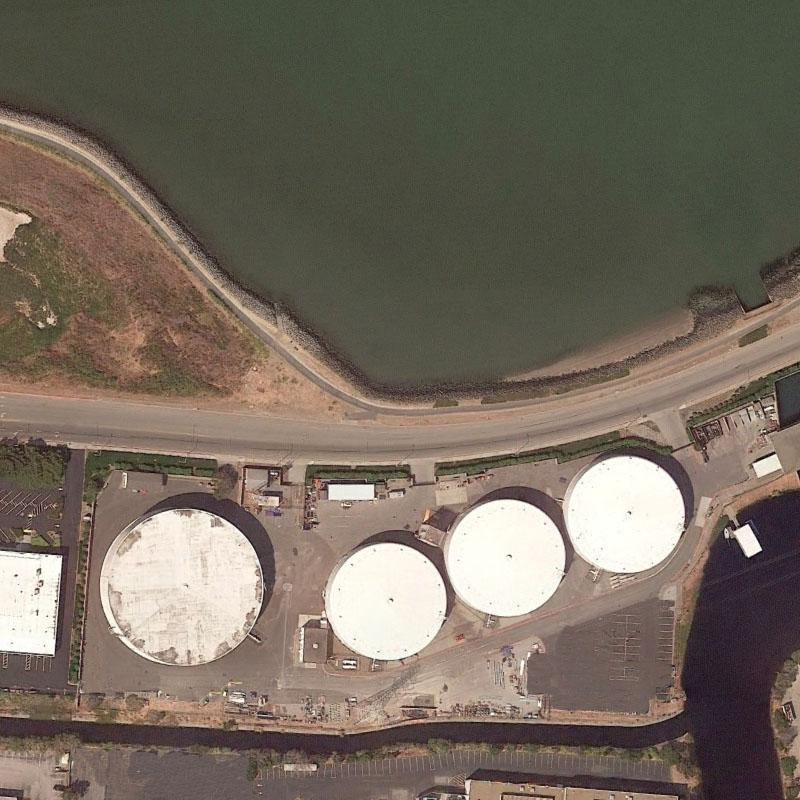

In [4]:
example = dataset["train"][0]
print(example.keys())

example["image"]

In [5]:
dataset["train"][0]

{'id': 1,
 'image_id': 1,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x800>,
 'file_name': 'images/DIOR_00014_0_0_0_800_800.jpg',
 'width': 800,
 'height': 800,
 'objects': {'id': [1, 2, 3, 4],
  'area': [25748.0, 14278.0, 14278.0, 14157.0],
  'bbox': [[99.0, 508.0, 164.0, 157.0],
   [324.0, 541.0, 121.0, 118.0],
   [443.0, 498.0, 121.0, 118.0],
   [563.0, 455.0, 121.0, 117.0]],
  'category': [0, 0, 0, 0],
  'attributes': None,
  'category_id': [0, 0, 0, 0],
  'iscrowd': [0, 0, 0, 0],
  'segmentation': [[[99.0, 508.0, 263.0, 508.0, 263.0, 665.0, 99.0, 665.0]],
   [[324.0, 541.0, 445.0, 541.0, 445.0, 659.0, 324.0, 659.0]],
   [[443.0, 498.0, 564.0, 498.0, 564.0, 616.0, 443.0, 616.0]],
   [[563.0, 455.0, 684.0, 455.0, 684.0, 572.0, 563.0, 572.0]]]}}

In [ ]:
import numpy as np
from PIL import Image, ImageDraw

# Get mapping from category id to category name
categories = dataset["train"].features["objects"]["category"].feature.names
print(categories)

label2id = {
    "Plane": 0,
    "Bridge": 1,
    "Intersection": 2,
    "Roundabout": 3,
    "Vehicle": 4,
    "Ship": 5,
}
id2label = {v: k for k, v in label2id.items()}

# Load image and annotations
image = dataset["train"][4]["image"]
print(dataset["train"][4]["file_name"])
annotations = dataset["train"][4]["objects"]

# Draw bounding boxes and labels
draw = ImageDraw.Draw(image)
for i in range(len(annotations["id"])):
    box = annotations["bbox"][i]
    class_idx = annotations["category"][i]
    x, y, w, h = tuple(box)
    draw.rectangle((x, y, x + w, y + h), outline="red", width=1)
    draw.text((x, y), id2label[class_idx], fill="white")

image

In [7]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
    do_resize=True,
    size={"width": image_size, "height": image_size},
    use_fast=True,
)

In [8]:
import albumentations as A

# train_augmentation_and_transform = A.Compose(
#     [
#         A.Perspective(p=0.1),
#         A.HorizontalFlip(p=0.5),
#         A.RandomBrightnessContrast(p=0.5),
#         A.HueSaturationValue(p=0.1),
#     ],
#     bbox_params=A.BboxParams(
#         format="coco", label_fields=["category"], clip=True, min_area=25, min_width=1, min_height=1
#     ),
# )

train_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="coco", label_fields=["category"], clip=True, min_area=25, min_width=1, min_height=1
    ),
)

# to make sure boxes are clipped to image size and there is no boxes with area < 1 pixel
validation_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="coco", label_fields=["category"], clip=True, min_area=1, min_width=1, min_height=1
    ),
)

In [9]:
from torch.utils.data import Dataset


class MSGODataset(Dataset):
    def __init__(self, dataset, image_processor, transform=None):
        self.dataset = dataset
        self.image_processor = image_processor
        self.transform = transform

    @staticmethod
    def format_image_annotations_as_coco(image_id, categories, boxes):
        """Format one set of image annotations to the COCO format

        Args:
            image_id (str): image id. e.g. "0001"
            categories (List[int]): list of categories/class labels corresponding to provided bounding boxes
            boxes (List[Tuple[float]]): list of bounding boxes provided in COCO format
                ([center_x, center_y, width, height] in absolute coordinates)

        Returns:
            dict: {
                "image_id": image id,
                "annotations": list of formatted annotations
            }
        """
        annotations = []
        for category, bbox in zip(categories, boxes, strict=False):
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": list(bbox),
                "iscrowd": 0,
                "area": bbox[2] * bbox[3],
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image_id = sample["image_id"]
        image = sample["image"]
        boxes = sample["objects"]["bbox"]
        categories = sample["objects"]["category"]

        # Convert image to RGB numpy array
        image = np.array(image.convert("RGB"))

        # Apply augmentations
        if self.transform:
            transformed = self.transform(image=image, bboxes=boxes, category=categories)
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]

        # Format annotations in COCO format for image_processor
        formatted_annotations = self.format_image_annotations_as_coco(image_id, categories, boxes)

        # Apply the image processor transformations: resizing, rescaling, normalization
        result = self.image_processor(images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

In [10]:
train_dataset = MSGODataset(dataset["train"], image_processor, transform=train_transform)
validation_dataset = MSGODataset(dataset["valid"], image_processor, transform=validation_transform)
test_dataset = MSGODataset(dataset["test"], image_processor, transform=validation_transform)

train_dataset[15]

{'pixel_values': tensor([[[0.5020, 0.4980, 0.5020,  ..., 0.4510, 0.4510, 0.4471],
          [0.5137, 0.5059, 0.5020,  ..., 0.4549, 0.4549, 0.4471],
          [0.5294, 0.5137, 0.5020,  ..., 0.4431, 0.4431, 0.4392],
          ...,
          [0.5843, 0.5922, 0.5882,  ..., 0.4431, 0.4471, 0.4510],
          [0.5725, 0.5686, 0.5647,  ..., 0.4196, 0.4118, 0.4039],
          [0.5451, 0.5412, 0.5490,  ..., 0.3843, 0.3647, 0.3451]],
 
         [[0.4510, 0.4471, 0.4510,  ..., 0.4196, 0.4235, 0.4196],
          [0.4627, 0.4549, 0.4510,  ..., 0.4235, 0.4196, 0.4196],
          [0.4784, 0.4627, 0.4510,  ..., 0.4118, 0.4078, 0.4039],
          ...,
          [0.5294, 0.5373, 0.5333,  ..., 0.4196, 0.4235, 0.4275],
          [0.5176, 0.5137, 0.5098,  ..., 0.3961, 0.3882, 0.3804],
          [0.4902, 0.4863, 0.4941,  ..., 0.3608, 0.3412, 0.3216]],
 
         [[0.4196, 0.4157, 0.4196,  ..., 0.3765, 0.3843, 0.3804],
          [0.4314, 0.4235, 0.4196,  ..., 0.3804, 0.3843, 0.3804],
          [0.4471, 0.431

In [ ]:
for i in [0, 3, 15, 16, 17]:
    sample = train_dataset[i]

    # De-normalize image
    image = sample["pixel_values"]
    print("Image tensor shape:", image.shape)
    image = image.numpy().transpose(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min()) * 255.0
    image = Image.fromarray(image.astype(np.uint8))

    # Convert boxes from [center_x, center_y, width, height] to [x, y, width, height] for visualization
    boxes = sample["labels"]["boxes"].numpy()
    print("Boxes shape:", boxes.shape)
    boxes[:, :2] = boxes[:, :2] - boxes[:, 2:] / 2
    w, h = image.size
    boxes = boxes * np.array([w, h, w, h])[None]

    categories = sample["labels"]["class_labels"].numpy()
    print("Categories shape:", categories.shape)

    # Draw boxes and labels on image
    draw = ImageDraw.Draw(image)
    for box, category in zip(boxes, categories, strict=False):
        x, y, w, h = box
        draw.rectangle([x, y, x + w, y + h], outline="red", width=1)
        draw.text((x, y), id2label[category], fill="white")

    display(image)

In [12]:
import torch


def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

In [13]:
from dataclasses import dataclass

import numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers.image_transforms import center_to_corners_format


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:
    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes, strict=False):
            for target, size in zip(target_batch, image_size_batch, strict=False):
                # here we have "yolo" format (x_center, y_center, width, height) in relative coordinates 0..1
                # and we need to convert it to "pascal" format (x_min, y_min, x_max, y_max) in absolute coordinates
                height, width = size
                boxes = torch.tensor(target["boxes"])
                boxes = center_to_corners_format(boxes)
                boxes = boxes * torch.tensor([[width, height, width, height]])

                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes, strict=False):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):
        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class, strict=False):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics


eval_compute_metrics_fn = MAPEvaluator(image_processor=image_processor, threshold=0.01, id2label=id2label)

In [14]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

Some weights of DFineForObjectDetection were not initialized from the model checkpoint at ustc-community/dfine-nano-coco and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 128]) in the checkpoint and torch.Size([6, 128]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 128]) in the checkpoint and torch.Size([6, 128]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 128]) in the checkpoint and torch.Size([6, 128]) in the model instantiated
- model.d

In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="d-fine-n-msgo-finetune-1",
    num_train_epochs=6,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=8,
    dataloader_num_workers=0,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to="tensorboard",  # or "wandb"
)

In [16]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    processing_class=image_processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Plane,Mar 100 Plane,Map Bridge,Mar 100 Bridge,Map Intersection,Mar 100 Intersection,Map Roundabout,Mar 100 Roundabout,Map Vehicle,Mar 100 Vehicle,Map Ship,Mar 100 Ship
1,No log,9.637072,0.000100,0.000300,0.000000,0.000000,0.000000,0.005200,0.000000,0.017900,0.032100,0.000000,0.000000,0.032100,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000500,0.128600,0.000000,0.000000
2,No log,9.358589,0.001700,0.008100,0.000100,0.000000,0.000000,0.031200,0.010800,0.020500,0.063300,0.000000,0.000000,0.111100,0.003600,0.020000,0.002100,0.033300,-1.000000,-1.000000,-1.000000,-1.000000,0.001100,0.200000,0.000000,0.000000
3,No log,9.302709,0.001900,0.003100,0.002800,0.000000,0.000000,0.013500,0.021400,0.021400,0.075600,0.000000,0.000000,0.096400,0.000000,0.000000,0.000000,0.016700,-1.000000,-1.000000,-1.000000,-1.000000,0.007400,0.285700,0.000000,0.000000
4,No log,8.962514,0.004400,0.014600,0.000300,0.000000,0.000000,0.015300,0.012800,0.042600,0.049700,0.000000,0.000000,0.101800,0.000000,0.000000,0.001800,0.041700,-1.000000,-1.000000,-1.000000,-1.000000,0.015600,0.157100,0.000000,0.000000
5,No log,8.350996,0.003500,0.007300,0.000400,0.000000,0.000800,0.011300,0.000000,0.050000,0.072700,0.000000,0.018200,0.124400,0.000500,0.035000,0.000200,0.041700,-1.000000,-1.000000,-1.000000,-1.000000,0.013400,0.214300,0.000000,0.000000
6,No log,7.838614,0.001100,0.003200,0.000400,0.000000,0.000000,0.005900,0.000000,0.029800,0.050200,0.000000,0.000000,0.054800,0.000100,0.015000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.004100,0.185700,0.000000,0.000000


There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.weight', 'bbox_embed.1.layers.0.bias', 'bbox_embed.1.layers.1.weight', 'bbox_embed.1.layers.1.bias', 'bbox_embed.1.layers.2.weight', 'bbox_embed.1.layers.2.bias', 'bbox_embed.2.layers.0.weight', 'bbox_embed.2.layers.0.bias', 'bbox_embed.2.layers.1.weight', 'bbox_embed.2.layers.1.bias', 'bbox_embed.2.layers.2.weight', 'bbox_embed.2.layers.2.bias'].


TrainOutput(global_step=78, training_loss=69.60995092147436, metrics={'train_runtime': 298.4462, 'train_samples_per_second': 2.01, 'train_steps_per_second': 0.261, 'total_flos': 2.5725558528e+16, 'train_loss': 69.60995092147436, 'epoch': 6.0})

In [17]:
from pprint import pprint

metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix="eval")
pprint(metrics)

{'epoch': 6.0,
 'eval_loss': 8.19385814666748,
 'eval_map': 0.0002,
 'eval_map_50': 0.0005,
 'eval_map_75': 0.0002,
 'eval_map_Bridge': 0.0,
 'eval_map_Intersection': -1.0,
 'eval_map_Plane': 0.0,
 'eval_map_Roundabout': -1.0,
 'eval_map_Ship': 0.0006,
 'eval_map_Vehicle': 0.0001,
 'eval_map_large': 0.0007,
 'eval_map_medium': 0.0,
 'eval_map_small': 0.0,
 'eval_mar_1': 0.0,
 'eval_mar_10': 0.0071,
 'eval_mar_100': 0.0571,
 'eval_mar_100_Bridge': 0.0,
 'eval_mar_100_Intersection': -1.0,
 'eval_mar_100_Plane': 0.0,
 'eval_mar_100_Roundabout': -1.0,
 'eval_mar_100_Ship': 0.2,
 'eval_mar_100_Vehicle': 0.0286,
 'eval_mar_large': 0.0762,
 'eval_mar_medium': 0.0,
 'eval_mar_small': 0.0,
 'eval_runtime': 1.744,
 'eval_samples_per_second': 11.468,
 'eval_steps_per_second': 1.72}
